In [1]:
#########################################################################
# # ! Moon Topographic-Gravitational-Potential Computation: PH vs SH
#########################################################################
# %% 
# # ! Setup
import pandas as pd
import pyshtools as pysh
import pygmt
import xarray as xr
import time
from datetime import datetime
from gravity_forward_numba import *

In [2]:
# # ! Start time
print("=" * 80)
print(f"Start time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

Start time: [2026-05-17 17:10:49]


In [3]:
# # ! Load Topo data
#### * Topography
lmax_shp = 359
res_top = 15.0/60.0 # degree
nc_file_Topo = f'output/moon_topo_Lshp{lmax_shp}_{int(60*res_top)}arcmin.nc'
data_Topo = xr.open_dataset(nc_file_Topo)
arr_Topo_moon = data_Topo['topo'].data

In [4]:
# # ! Load TGP data: SH vs PH
#### * SH
max_nmax = 7
nc_file_SH = f'output/moon_topo_gravity_Lshp{lmax_shp}_nmax{max_nmax}.nc'
data_SH = xr.open_dataset(nc_file_SH)
gn_SH = data_SH['gx'].data[::max_nmax, ::max_nmax]
ge_SH = data_SH['gy'].data[::max_nmax, ::max_nmax]
gd_SH = data_SH['gz'].data[::max_nmax, ::max_nmax]
#### * PH
out_res = 15.0/60.0 # degree
in_res_1 = 15.0/60.0 # degree
in_res_2 = 6.0/60.0 # degree
nc_file_PH_1 = (f"output/moon_topo_gravity_in{int(in_res_1*60)}arcmin"
                f"_out{int(out_res*60)}arcmin.nc")
nc_file_PH_2 = (f"output/moon_topo_gravity_in{int(in_res_2*60)}arcmin"
                f"_out{int(out_res*60)}arcmin.nc")
data_PH_1 = xr.open_dataset(nc_file_PH_1)
data_PH_2 = xr.open_dataset(nc_file_PH_2)
gn_PH_1 = data_PH_1['gN'].data
ge_PH_1 = data_PH_1['gE'].data
gd_PH_1 = data_PH_1['gD'].data
gn_PH_2 = data_PH_2['gN'].data
ge_PH_2 = data_PH_2['gE'].data
gd_PH_2 = data_PH_2['gD'].data
#### * Diff = PH - SH
d_gn_1, d_ge_1, d_gd_1 = gn_PH_1 - gn_SH, ge_PH_1 - ge_SH, gd_PH_1 - gd_SH
d_gn_2, d_ge_2, d_gd_2 = gn_PH_2 - gn_SH, ge_PH_2 - ge_SH, gd_PH_2 - gd_SH
d_gn_1[[0, -1], :] = 0.0
d_ge_1[[0, -1], :] = 0.0
d_gd_1[[0, -1], :] = 0.0
d_gn_2[[0, -1], :] = 0.0
d_ge_2[[0, -1], :] = 0.0
d_gd_2[[0, -1], :] = 0.0
#### * Summary statistics
g_SH = {'N': gn_SH, 'E': ge_SH, 'D': gd_SH}
g_PH_1 = {'N': gn_PH_1, 'E': ge_PH_1, 'D': gd_PH_1}
g_PH_2 = {'N': gn_PH_2, 'E': ge_PH_2, 'D': gd_PH_2}
d_g_1 = {'N': d_gn_1, 'E': d_ge_1, 'D': d_gd_1}
d_g_2 = {'N': d_gn_2, 'E': d_ge_2, 'D': d_gd_2}
print('-' * 80)
print('Gravity Vector components in mGal')
print(f"{'Type':18s} | {'Comp':4s} | {'min':>9s} | {'max':>9s} |"
      f" {'mean':>9s} | {'std':>9s}")
print('-' * 80)
datasets = {'SH': g_SH, 'PH (15 arcmin)': g_PH_1, 'PH (6 arcmin)': g_PH_2, 
            'Diff (15 arcmin)': d_g_1, 'Diff (6 arcmin)': d_g_2}
for typ in ['SH', 'PH (15 arcmin)', 'PH (6 arcmin)', 
            'Diff (15 arcmin)', 'Diff (6 arcmin)']:
    for comp in ['N', 'E', 'D']:
        data = datasets[typ][comp]
        print(f"{typ:18s} | {f'g{comp}':4s} |"
              f" {data.min():9.4f} | {data.max():9.4f} |"
              f" {data.mean():9.4f} | {data.std():9.4f}")
    print('=' * 80)

--------------------------------------------------------------------------------
Gravity Vector components in mGal
Type               | Comp |       min |       max |      mean |       std
--------------------------------------------------------------------------------
SH                 | gN   | -488.8082 |  933.4147 |   10.3820 |  154.3514
SH                 | gE   | -551.9941 |  606.5575 |    0.0197 |  150.2317
SH                 | gD   | -721.8590 | 1189.4579 |  -35.0952 |  246.4136
PH (15 arcmin)     | gN   | -486.9639 |  926.2217 |   10.3856 |  154.2915
PH (15 arcmin)     | gE   | -548.6204 |  605.3110 |    0.0197 |  150.2471
PH (15 arcmin)     | gD   | -721.7818 | 1182.6341 |  -36.0165 |  246.2114
PH (6 arcmin)      | gN   | -488.5107 |  932.2260 |   10.3829 |  154.4438
PH (6 arcmin)      | gE   | -551.4422 |  606.3592 |    0.0197 |  150.3391
PH (6 arcmin)      | gD   | -721.8638 | 1187.8352 |  -35.2429 |  246.3798
Diff (15 arcmin)   | gN   |  -12.0679 |   12.5141 |    0.0033 | 

In [5]:
# # ! Load Top-N largest |gD| errors
df_errors = pd.read_csv('output/Moon_gD_errors.csv')
err_lat = df_errors['Lat_deg'].values
err_lon = df_errors['Lon_deg'].values

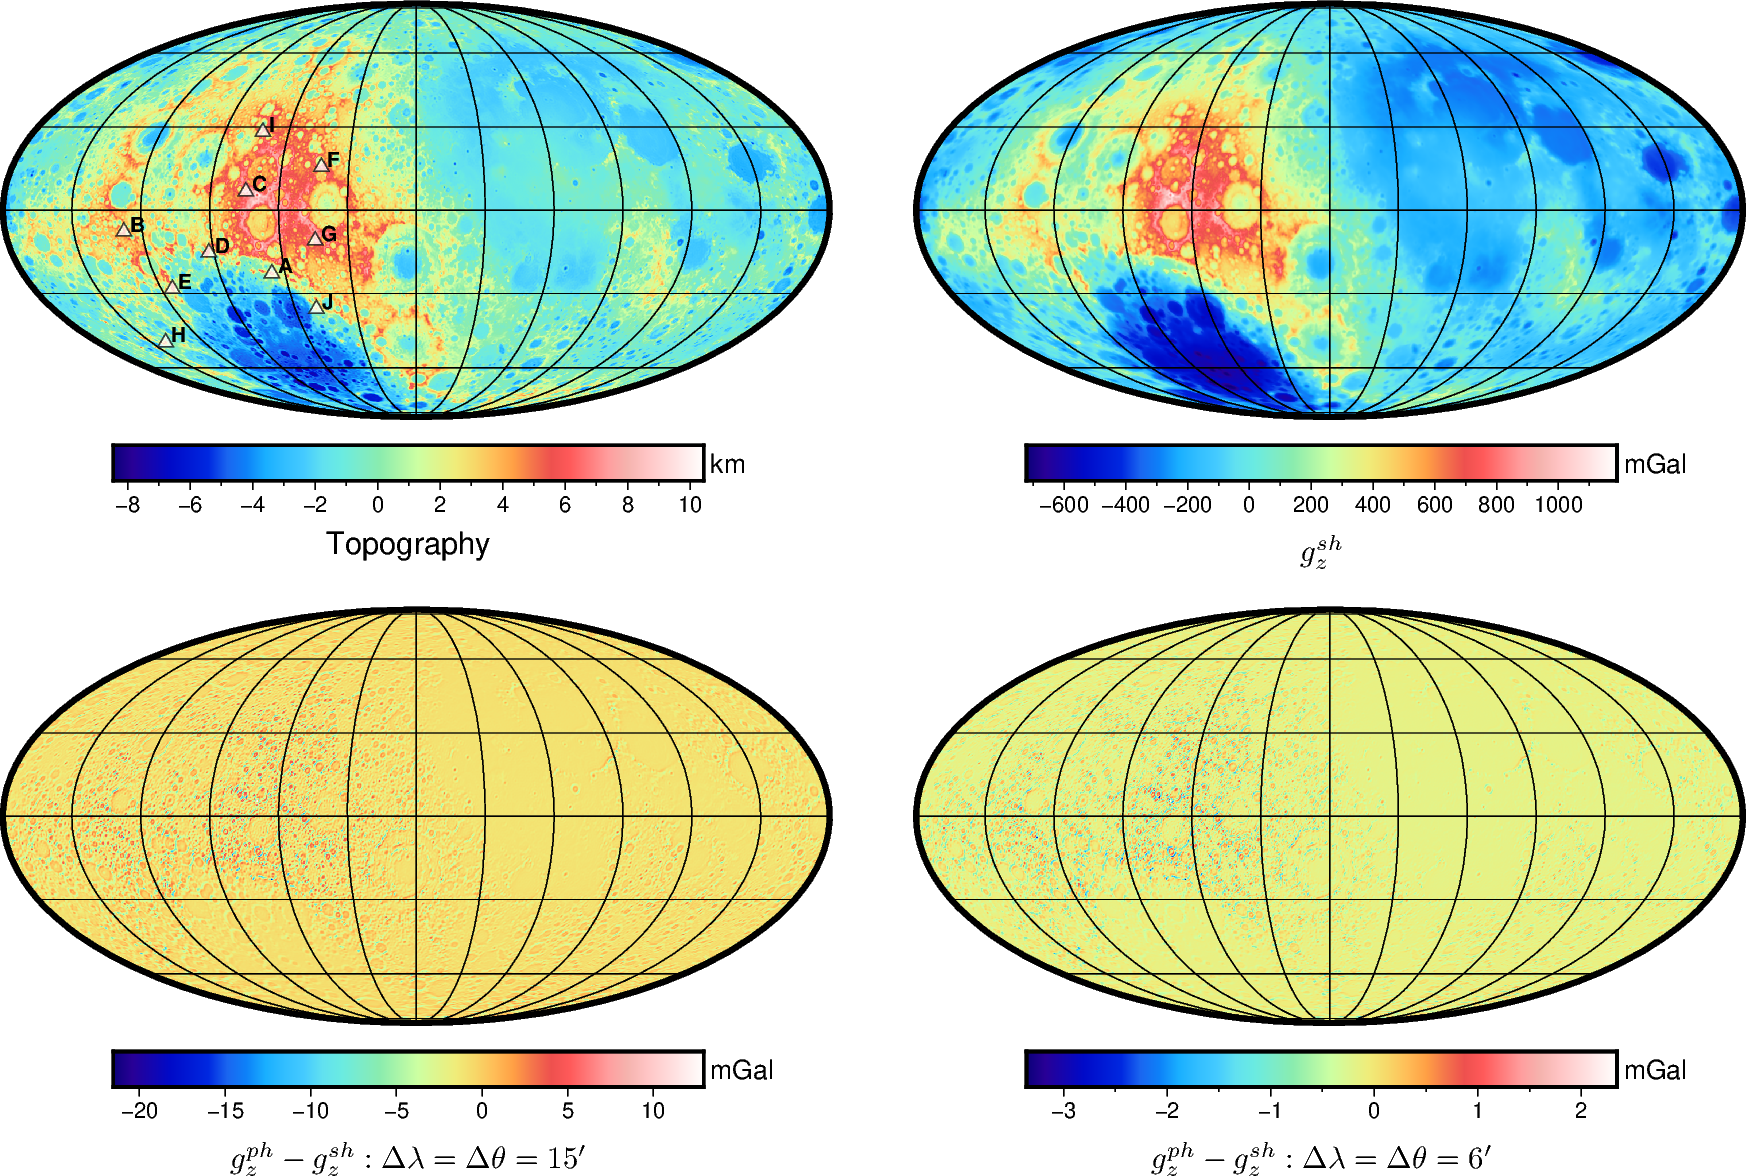

In [6]:
# # ! Mapping: SH vs PH
err_txt = ['A','B','C','D','E','F','G','H','I','J']
xr_Topo = pysh.SHGrid.from_array(arr_Topo_moon).to_xarray()
xr_gd_SH = pysh.SHGrid.from_array(gd_SH).to_xarray()
xr_d_gd_1 = pysh.SHGrid.from_array(d_gd_1).to_xarray()
xr_d_gd_2 = pysh.SHGrid.from_array(d_gd_2).to_xarray()
fig = pygmt.Figure()
with fig.subplot(nrows=2, ncols=2, figsize=('14c', '8.8c'), margins="0.5c"):
    with fig.set_panel(panel=0): 
        fig.grdimage(grid=xr_Topo, projection="W-90/7c", cmap="haxby", frame="g30")
        fig.plot(x=err_lon, y=err_lat, 
                 projection="W-90/7c", transparency=25,
                 style="t0.15c", fill="white", pen="0.25p,black")
        fig.text(x=err_lon, y=err_lat, text=err_txt, 
                 projection="W-90/7c", justify="BL", 
                 offset="0.05c/0.0c", font="5p,Helvetica-Bold,black")
        fig.colorbar(position="JBC+o0.3/0.2i+w5c/0.3h", 
                     frame=["a2f1", "x+lTopography", "y+lkm"])    
    with fig.set_panel(panel=1): 
        fig.grdimage(grid=xr_gd_SH, projection="W-90/7c", cmap="haxby", frame="g30")
        fig.colorbar(position="JBC+o0.3/0.2i+w5c/0.3h", 
                     frame=["a200f100", "x+l@[ g_z^{sh} @[", "y+lmGal"])    
    with fig.set_panel(panel=2): 
        fig.grdimage(grid=xr_d_gd_1, projection="W-90/7c", cmap="haxby", frame="g30")
        xlabel = r"@[ g_z^{ph}-g_z^{sh}: \Delta \lambda = \Delta \theta = 15^{\prime}@["
        fig.colorbar(position="JBC+o0.3/0.2i+w5c/0.3h", 
                     frame=["a5f5", f"x+l{xlabel}", "y+lmGal"])    
    with fig.set_panel(panel=3): 
        fig.grdimage(grid=xr_d_gd_2, projection="W-90/7c", cmap="haxby", frame="g30")
        xlabel = r"@[ g_z^{ph}-g_z^{sh}: \Delta \lambda = \Delta \theta = 6^{\prime}@["
        fig.colorbar(position="JBC+o0.3/0.2i+w5c/0.3h", 
                     frame=["a1f0.5", f"x+l{xlabel}", "y+lmGal"])    
fig.savefig('Moon_TopoGz_PH_vs_SH_2.png', dpi=400)
fig.show(width=800)

In [7]:
# # ! End time
print("=" * 80)
print(f"End time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

End time: [2026-05-17 17:10:54]
